In [2]:
# !pip install xgboost
# !pip install umap-learn
# !pip install numpy pandas scipy mne
# !pip install mne-connectivity
# !pip install openpyxl
# !pip install shap
import os, re, glob
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, balanced_accuracy_score, f1_score, recall_score, average_precision_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.decomposition import PCA

from xgboost import XGBClassifier
from joblib import Parallel, delayed
from scipy.stats import randint, uniform, loguniform

df = pd.read_excel("processeddata/Randomization factors and Primary outcome.xlsx")
diff = df[df['Event Name'].isin(['T1', 'T2'])].pivot_table(
    index='Patient number', columns='Event Name', values='Pain Unpleasantness'
).dropna()
diff['Diff'] = diff['T2'] - diff['T1']
output_dir = "processeddata/"
##########################################
# ----------------------------
# Add patient-level covariates
# ----------------------------
cov_path = "processeddata/eeg107_final.csv"
cov = pd.read_csv(cov_path)

# Keep only what we need
cov = cov[["Patient number", "Sex", "Married", "Group assignment", "CancerStage_3"]].copy()

# Normalize types
cov["Patient number"] = cov["Patient number"].astype(int)
cov["Married"] = cov["Married"].astype(int)

# Ensure stable one-hot columns even if a category is missing in some subset
sex_cats   = ["Female", "Male"]
group_cats = ["NFB", "NFB+DL", "DL"]
stage_cats = ["I_II", "III", "IV"]

cov["Sex"] = pd.Categorical(cov["Sex"], categories=sex_cats)
cov["Group assignment"] = pd.Categorical(cov["Group assignment"], categories=group_cats)
cov["CancerStage_3"] = pd.Categorical(cov["CancerStage_3"], categories=stage_cats)

# One-hot encode categoricals; keep Married as numeric
cov_oh = pd.get_dummies(
    cov,
    columns=["Sex", "Group assignment", "CancerStage_3"],
    drop_first=False
)

# Build mapping: pid -> covariate vector (fixed column order)
cov_feat_cols = [c for c in cov_oh.columns if c != "Patient number"]
cov_feat_cols = ["Married"] + [c for c in cov_feat_cols if c != "Married"]  # put Married first (optional)

pid_to_cov = {
    int(row["Patient number"]): row[cov_feat_cols].to_numpy(dtype=float)
    for _, row in cov_oh.iterrows()
}

print("Covariate feature columns:", cov_feat_cols)
print("Covariate feature dim:", len(cov_feat_cols))

median_threshold = -2.00
n_iter = 300  # in RandomizedSearchCV
feature_reduction = "none"   # "none" | "pca"
BAND_FEATS_MODE = "all5"   # "mean" | "mean_std" | "mean_median" | "all5"
n_splits = 5
random_state = 42
min_patients_required = 20

USE_COVARIATES = True   # <- set False to remove patient-level covariates
# Optional: if False, we skip loading covariate CSV entirely.
cov_feat_cols = []
pid_to_cov = {}   # pid -> cov vector

if USE_COVARIATES:
    cov_path = "processeddata/eeg107_final.csv"
    cov = pd.read_csv(cov_path)

    # Keep only what we need
    cov = cov[["Patient number", "Sex", "Married", "Group assignment", "CancerStage_3"]].copy()

    # Normalize types
    cov["Patient number"] = cov["Patient number"].astype(int)
    cov["Married"] = cov["Married"].astype(int)

    # Ensure stable one-hot columns even if a category is missing in some subset
    sex_cats   = ["Female", "Male"]
    group_cats = ["NFB", "NFB+DL", "DL"]
    stage_cats = ["I_II", "III", "IV"]

    cov["Sex"] = pd.Categorical(cov["Sex"], categories=sex_cats)
    cov["Group assignment"] = pd.Categorical(cov["Group assignment"], categories=group_cats)
    cov["CancerStage_3"] = pd.Categorical(cov["CancerStage_3"], categories=stage_cats)

    # One-hot encode categoricals; keep Married as numeric
    cov_oh = pd.get_dummies(
        cov,
        columns=["Sex", "Group assignment", "CancerStage_3"],
        drop_first=False
    )

    # Build mapping: pid -> covariate vector (fixed column order)
    cov_feat_cols = [c for c in cov_oh.columns if c != "Patient number"]
    cov_feat_cols = ["Married"] + [c for c in cov_feat_cols if c != "Married"]  # put Married first (optional)

    pid_to_cov = {
        int(row["Patient number"]): row[cov_feat_cols].to_numpy(dtype=float)
        for _, row in cov_oh.iterrows()
    }

    print("Covariates: ENABLED")
    print("Covariate feature columns:", cov_feat_cols)
    print("Covariate feature dim:", len(cov_feat_cols))
else:
    print("Covariates: DISABLED")

# --------------------------------------------------------
# User config
# Feature reduction for XGBoost:
# - XGBoost does NOT need scaling.
# - PCA is optional; sometimes helps, sometimes hurts.

#guide
# Z_PeakFreq_Hz           ['Theta', 'Alpha'] #7,7 /10  #7,7,2,1
# Z_FFT_Coherence         ['Beta',  'Beta2', 'Beta3', 'HighBeta']  # 8,6,6,5 /10
# Z_FFT_abs_bandpower_uV2 ['Alpha2',  'HighBeta', 'Alpha', 'Theta'] # 9, 6, 5,4
# Z_FFT_PhaseLag_PLI      ['Delta', 'HighBeta', 'Alpha1']  #9,9,7
# --------------------------------------------------------



SHEET_BANDS = {
    #"Z_PeakFreq_Hz":           ["Theta", "Alpha"],
    "Z_FFT_Coherence":         [ "Beta2", "Beta3", "HighBeta"], # ["Beta", "HighBeta", "Beta2", "Beta3"],
    "Z_FFT_abs_bandpower_uV2": ['Alpha2',  'HighBeta','Alpha'],
    "Z_FFT_PhaseLag_PLI":      ['Delta', 'HighBeta', 'Alpha1']}

# SHEET_BANDS = {
#   "Z_FFT_abs_bandpower_uV2": ["Alpha2","HighBeta","Alpha"],
#   "Z_FFT_PhaseLag_PLI":      ["Delta","HighBeta","Alpha1"],
# }
# SHEET_BANDS = {
#   "Z_FFT_Coherence":    ["Beta2","Beta3","HighBeta"],
#   "Z_FFT_PhaseLag_PLI": ["Delta","HighBeta","Alpha1"],
# }
# SHEET_BANDS = {
#   "Z_FFT_Coherence":         ["Beta2","Beta3","HighBeta"],
#   "Z_FFT_abs_bandpower_uV2": ["Alpha2","HighBeta","Alpha"],
# }
# --------------------------------------------------------
# Utilities
# --------------------------------------------------------
def parse_patient_id_from_filename(xlsx_path: str):
    base = os.path.basename(xlsx_path)
    m = re.search(r"CIPN3(\d{3})", base)
    return int(m.group(1)) if m else None

def build_samples(output_dir: str):
    files = sorted(glob.glob(os.path.join(output_dir, "CIPN3*.xlsx")))
    rows = []
    for f in files:
        pid = parse_patient_id_from_filename(f)
        if pid is None:
            continue
        rows.append((pid, f))
    return rows

def feats_from_single_band_column(df_band: pd.DataFrame) -> np.ndarray:
    """
    df_band: 1-col dataframe for one band.

    Modes:
      - "mean"        -> [global_mean]                       (1 feat)
      - "mean_std"    -> [global_mean, global_std]           (2 feats)
      - "mean_median" -> [global_mean, global_median]        (2 feats)
      - "all5"        -> [col_mean, col_std, g_mean, g_std, g_med] (5 feats)
    """
    A = df_band.values.astype(float)
    A = np.nan_to_num(A, nan=0.0, posinf=0.0, neginf=0.0)

    g_mean = float(A.mean())
    g_std  = float(A.std())
    g_med  = float(np.median(A))

    if BAND_FEATS_MODE == "mean":
        return np.array([g_mean], dtype=float)
    if BAND_FEATS_MODE == "mean_std":
        return np.array([g_mean, g_std], dtype=float)
    if BAND_FEATS_MODE == "mean_median":
        return np.array([g_mean, g_med], dtype=float)
    if BAND_FEATS_MODE == "all5":
        col_mean = float(A.mean(axis=0)[0])
        col_std  = float(A.std(axis=0)[0])
        return np.array([col_mean, col_std, g_mean, g_std, g_med], dtype=float)

    raise ValueError("Invalid BAND_FEATS_MODE")

def load_one_file_all_features(xlsx_path: str, sheet_bands: dict) -> np.ndarray:
    """
    Concatenate features across all requested sheets/bands.
    If a sheet/band is missing, we fill that band's feature block with zeros.
    """
    feat_dims = {"mean": 1, "mean_std": 2, "mean_median": 2, "all5": 5}
    feats_per_band = feat_dims.get(BAND_FEATS_MODE, 5)

    feats = []
    for sheet, bands in sheet_bands.items():
        try:
            df_sheet = pd.read_excel(xlsx_path, sheet_name=sheet, index_col=0)
        except Exception:
            df_sheet = None

        for b in bands:
            if df_sheet is not None and b in df_sheet.columns:
                feats.append(feats_from_single_band_column(df_sheet[[b]]))
            else:
                feats.append(np.zeros(feats_per_band, dtype=float))
    return np.concatenate(feats, axis=0)

def mean_std(x):
    x = np.asarray(x, dtype=float)
    return float(x.mean()), float(x.std())

def _feat_for_file(pid, f):
    eeg_feat = load_one_file_all_features(f, SHEET_BANDS)

    if USE_COVARIATES:
        cov_feat = pid_to_cov.get(int(pid), np.zeros(len(cov_feat_cols), dtype=float))
        return np.concatenate([eeg_feat, cov_feat], axis=0)

    return eeg_feat

# ----------------------------
# Build (X, y, groups)
# ----------------------------
rows = build_samples(output_dir)
rows = [(pid, f) for (pid, f) in rows if pid in diff.index]

if len(rows) == 0:
    raise RuntimeError("No samples found after filtering for labeled patients.")

print(f"Found {len(rows)} files with labels. Building patient-level labels...")

unique_pids = sorted(set([pid for pid, _ in rows]))
y_patient = (diff.loc[unique_pids, "Diff"] >= median_threshold).astype(int)
pid_to_y = y_patient.to_dict()

y = np.asarray([int(pid_to_y[pid]) for pid, _ in rows], dtype=int)
groups = np.asarray([pid for pid, _ in rows], dtype=int)
kept_files = [f for _, f in rows]

print("Unique patients:", len(np.unique(groups)))
print(f"Threshold: {median_threshold} | Neg: {(y==0).sum()} Pos: {(y==1).sum()} | AP baseline: {y.mean():.3f}")

if len(np.unique(groups)) < min_patients_required:
    raise RuntimeError(f"Too few unique patients: {len(np.unique(groups))} (< {min_patients_required})")

total_bands = sum(len(v) for v in SHEET_BANDS.values())
feat_dims = {"mean": 1, "mean_std": 2, "mean_median": 2, "all5": 5}
feats_per_band = feat_dims.get(BAND_FEATS_MODE, 5)
feature_dim = total_bands * feats_per_band

print(f"\nBuilding X using ALL sheets/bands: total_bands={total_bands} -> feature_dim={feature_dim} "
      f"(mode='{BAND_FEATS_MODE}', {feats_per_band} feats/band)")
print("Sheets/bands:")
for k, v in SHEET_BANDS.items():
    print(f"  - {k}: {v}")

print("\nParallel feature extraction (EEG + covariates)...")
X_list = Parallel(n_jobs=-1, prefer="processes", verbose=10)(
    delayed(_feat_for_file)(pid, f) for pid, f in rows
)
X = np.vstack(X_list).astype(float)
print("X shape:", X.shape)

total_feature_dim = feature_dim + len(cov_feat_cols)
print("EEG feature_dim:", feature_dim, "| cov_dim:", len(cov_feat_cols), "| total_dim:", total_feature_dim)


# ----------------------------
# CV + model
# ----------------------------
cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

scoring = {
    "bal_acc": make_scorer(balanced_accuracy_score),
    "f1": make_scorer(f1_score, zero_division=0),
    "recall_pos": make_scorer(recall_score, pos_label=1, zero_division=0),
    "recall_neg": make_scorer(recall_score, pos_label=0, zero_division=0),
    "ap": make_scorer(average_precision_score, needs_proba=True),
}

# XGBoost class imbalance handling
neg = int((y == 0).sum())
pos = int((y == 1).sum())
scale_pos_weight = (neg / pos) if pos > 0 else 1.0
print(f"\nClass counts: neg={neg} pos={pos} -> scale_pos_weight={scale_pos_weight:.3f}")

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",     # change to "gpu_hist" if you want GPU and it works on your setup
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
)

if feature_reduction == "none":
    pipe = Pipeline([
        ("clf", xgb),
    ])
    param_dist = {
        "clf__n_estimators": randint(200, 2000),
        "clf__max_depth": randint(2, 8),
        "clf__learning_rate": loguniform(1e-3, 2e-1),   # better than uniform for LR
        "clf__subsample": uniform(0.5, 0.5),            # 0.5–1.0
        "clf__colsample_bytree": uniform(0.5, 0.5),     # 0.5–1.0
        "clf__min_child_weight": randint(1, 15),
        "clf__gamma": loguniform(1e-3, 10.0),
        "clf__reg_lambda": loguniform(1e-2, 100.0),
        "clf__reg_alpha": loguniform(1e-3, 10.0),
    }

elif feature_reduction == "pca":
    # PCA needs scaling
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(random_state=42)),
        ("clf", xgb),
    ])
    param_dist = {
        "pca__n_components": randint(5, 31),         # 5–30
        "clf__n_estimators": randint(200, 1200),
        "clf__max_depth": randint(2, 6),
        "clf__learning_rate": uniform(0.01, 0.19),   # 0.01–0.20
        "clf__subsample": uniform(0.6, 0.4),         # 0.6–1.0
        "clf__colsample_bytree": uniform(0.6, 0.4),  # 0.6–1.0
        "clf__min_child_weight": randint(1, 8),
        "clf__reg_lambda": uniform(0.5, 9.5),        # 0.5–10
    }
else:
    raise ValueError("feature_reduction must be one of: 'none', 'pca'")

print(f"\nRunning SIMPLE 5-fold patient-wise CV with XGBoost (feature_reduction='{feature_reduction}')")
rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=n_iter,                 # try 50–150
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
    random_state=42,
)

rs.fit(X, y, groups=groups)

print("\n" + "="*90)
print("Best params:", rs.best_params_)
print(f"Best mean CV balanced_accuracy: {rs.best_score_:.3f}")

best_est = rs.best_estimator_

# Fold-by-fold TRAIN + TEST metrics (best estimator)
fold_metrics_test  = {k: [] for k in scoring.keys()}
fold_metrics_train = {k: [] for k in scoring.keys()}

# --- BEFORE the loop ---
cms_train, cms_test = [], []

print("\nFold-by-fold metrics (best estimator):")
for fold_i, (tr, te) in enumerate(cv.split(X, y, groups=groups), 1):
    best_est.fit(X[tr], y[tr])

    # --- TRAIN ---
    proba_tr = best_est.predict_proba(X[tr])[:, 1]
    pred_tr  = (proba_tr >= 0.5).astype(int)

    ba_tr = balanced_accuracy_score(y[tr], pred_tr)
    f1_tr = f1_score(y[tr], pred_tr, zero_division=0)
    rp_tr = recall_score(y[tr], pred_tr, pos_label=1, zero_division=0)
    rn_tr = recall_score(y[tr], pred_tr, pos_label=0, zero_division=0)
    ap_tr = average_precision_score(y[tr], proba_tr)

    fold_metrics_train["bal_acc"].append(ba_tr)
    fold_metrics_train["f1"].append(f1_tr)
    fold_metrics_train["recall_pos"].append(rp_tr)
    fold_metrics_train["recall_neg"].append(rn_tr)
    fold_metrics_train["ap"].append(ap_tr)

    # TRAIN CM
    cm_tr = confusion_matrix(y[tr], pred_tr, labels=[0, 1])
    cms_train.append(cm_tr)

    # --- TEST ---
    proba_te = best_est.predict_proba(X[te])[:, 1]
    pred_te  = (proba_te >= 0.5).astype(int)

    ba_te = balanced_accuracy_score(y[te], pred_te)
    f1_te = f1_score(y[te], pred_te, zero_division=0)
    rp_te = recall_score(y[te], pred_te, pos_label=1, zero_division=0)
    rn_te = recall_score(y[te], pred_te, pos_label=0, zero_division=0)
    ap_te = average_precision_score(y[te], proba_te)

    fold_metrics_test["bal_acc"].append(ba_te)
    fold_metrics_test["f1"].append(f1_te)
    fold_metrics_test["recall_pos"].append(rp_te)
    fold_metrics_test["recall_neg"].append(rn_te)
    fold_metrics_test["ap"].append(ap_te)

    # TEST CM
    cm_te = confusion_matrix(y[te], pred_te, labels=[0, 1])
    cms_test.append(cm_te)

    # Print fold info
    print(f"\nFold {fold_i}/{n_splits} CM (TRAIN):")
    print(cm_tr)
    print(f"Fold {fold_i}/{n_splits} CM (TEST):")
    print(cm_te)

    print(f"  Fold {fold_i}/{n_splits} "
          f"| TRAIN: bal_acc={ba_tr:.3f} AP={ap_tr:.3f} r+={rp_tr:.3f} r-={rn_tr:.3f} F1={f1_tr:.3f} "
          f"| TEST:  bal_acc={ba_te:.3f} AP={ap_te:.3f} r+={rp_te:.3f} r-={rn_te:.3f} F1={f1_te:.3f}")


print("\n" + "="*90)
ba_m, ba_s = mean_std(fold_metrics_train["bal_acc"])
ap_m, ap_s = mean_std(fold_metrics_train["ap"])
rp_m, rp_s = mean_std(fold_metrics_train["recall_pos"])
rn_m, rn_s = mean_std(fold_metrics_train["recall_neg"])
f1_m, f1_s = mean_std(fold_metrics_train["f1"])
print(f"TRAIN summary | bal_acc={ba_m:.3f}±{ba_s:.3f} | AP={ap_m:.3f}±{ap_s:.3f} | "
      f"recall_pos={rp_m:.3f}±{rp_s:.3f} | recall_neg={rn_m:.3f}±{rn_s:.3f} | F1={f1_m:.3f}±{f1_s:.3f}")

ba_m, ba_s = mean_std(fold_metrics_test["bal_acc"])
ap_m, ap_s = mean_std(fold_metrics_test["ap"])
rp_m, rp_s = mean_std(fold_metrics_test["recall_pos"])
rn_m, rn_s = mean_std(fold_metrics_test["recall_neg"])
f1_m, f1_s = mean_std(fold_metrics_test["f1"])
print(f"TEST  summary | bal_acc={ba_m:.3f}±{ba_s:.3f} | AP={ap_m:.3f}±{ap_s:.3f} | "
      f"recall_pos={rp_m:.3f}±{rp_s:.3f} | recall_neg={rn_m:.3f}±{rn_s:.3f} | F1={f1_m:.3f}±{f1_s:.3f}")

# --- AFTER the loop: TRAIN CM summary ---
cms_train_arr = np.stack(cms_train, axis=0)   # (n_splits, 2, 2)
cm_tr_sum  = cms_train_arr.sum(axis=0)
cm_tr_mean = cms_train_arr.mean(axis=0)

print("\n" + "="*90)
print("len(cms_train) =", len(cms_train))   # should be 5
print("Sum CM over folds (TRAIN):")
print(cm_tr_sum)
print("\nMean CM over folds (TRAIN):")
print(cm_tr_mean)

# --- AFTER the loop: TEST CM summary ---
cms_test_arr = np.stack(cms_test, axis=0)    # (n_splits, 2, 2)
cm_te_sum  = cms_test_arr.sum(axis=0)
cm_te_mean = cms_test_arr.mean(axis=0)

print("\n" + "="*90)
print("len(cms_test) =", len(cms_test))     # should be 5
# print("Sum CM over folds (TEST):")
print(cm_tr_sum)
print(cm_te_sum)
# print("\nMean CM over folds (TEST):")
# print(cm_te_mean)

Covariate feature columns: ['Married', 'Sex_Female', 'Sex_Male', 'Group assignment_NFB', 'Group assignment_NFB+DL', 'Group assignment_DL', 'CancerStage_3_I_II', 'CancerStage_3_III', 'CancerStage_3_IV']
Covariate feature dim: 9
Covariates: ENABLED
Covariate feature columns: ['Married', 'Sex_Female', 'Sex_Male', 'Group assignment_NFB', 'Group assignment_NFB+DL', 'Group assignment_DL', 'CancerStage_3_I_II', 'CancerStage_3_III', 'CancerStage_3_IV']
Covariate feature dim: 9
Found 108 files with labels. Building patient-level labels...
Unique patients: 107
Threshold: -2.0 | Neg: 54 Pos: 54 | AP baseline: 0.500

Building X using ALL sheets/bands: total_bands=9 -> feature_dim=45 (mode='all5', 5 feats/band)
Sheets/bands:
  - Z_FFT_Coherence: ['Beta2', 'Beta3', 'HighBeta']
  - Z_FFT_abs_bandpower_uV2: ['Alpha2', 'HighBeta', 'Alpha']
  - Z_FFT_PhaseLag_PLI: ['Delta', 'HighBeta', 'Alpha1']

Parallel feature extraction (EEG + covariates)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done  22 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  44 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1981270242907059s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  57 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done  70 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done  92 out of 108 | elapsed:    1.3s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done 103 out of 108 | elapsed:    1.3s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 108 out of 108 | elapsed:    1.4s finished


X shape: (108, 54)
EEG feature_dim: 45 | cov_dim: 9 | total_dim: 54

Class counts: neg=54 pos=54 -> scale_pos_weight=1.000

Running SIMPLE 5-fold patient-wise CV with XGBoost (feature_reduction='none')
Fitting 5 folds for each of 300 candidates, totalling 1500 fits

Best params: {'clf__colsample_bytree': np.float64(0.9018017677207676), 'clf__gamma': np.float64(0.10491246574185645), 'clf__learning_rate': np.float64(0.1680302027096044), 'clf__max_depth': 6, 'clf__min_child_weight': 7, 'clf__n_estimators': 1212, 'clf__reg_alpha': np.float64(0.4695480001817503), 'clf__reg_lambda': np.float64(3.456886280594569), 'clf__subsample': np.float64(0.5829774476478925)}
Best mean CV balanced_accuracy: 0.658

Fold-by-fold metrics (best estimator):

Fold 1/5 CM (TRAIN):
[[32 11]
 [12 31]]
Fold 1/5 CM (TEST):
[[8 3]
 [5 6]]
  Fold 1/5 | TRAIN: bal_acc=0.733 AP=0.799 r+=0.721 r-=0.744 F1=0.729 | TEST:  bal_acc=0.636 AP=0.654 r+=0.545 r-=0.727 F1=0.600

Fold 2/5 CM (TRAIN):
[[34  9]
 [12 31]]
Fold 2/5 CM

In [3]:
# --- AFTER the loop: TRAIN CM summary ---
cms_train_arr = np.stack(cms_train, axis=0)   # (n_splits, 2, 2)
cm_tr_sum  = cms_train_arr.sum(axis=0)
cm_tr_mean = cms_train_arr.mean(axis=0)

# --- AFTER the loop: TEST CM summary ---
cms_test_arr = np.stack(cms_test, axis=0)     # (n_splits, 2, 2)
cm_te_sum  = cms_test_arr.sum(axis=0)
cm_te_mean = cms_test_arr.mean(axis=0)

def balacc_from_cm(cm):
    tn, fp = cm[0, 0], cm[0, 1]
    fn, tp = cm[1, 0], cm[1, 1]
    rneg = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    rpos = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return 0.5 * (rneg + rpos)

def acc_from_cm(cm):
    return (cm[0,0] + cm[1,1]) / cm.sum() if cm.sum() > 0 else 0.0

print("\n" + "="*90)
print("Mean fold bal_acc (TRAIN):", np.mean(fold_metrics_train["bal_acc"]))
print("Mean fold bal_acc (TEST) :", np.mean(fold_metrics_test["bal_acc"]))

# pooled (SUM CM) metrics
print("\nPooled from SUM CM (TRAIN):")
print("  acc     :", acc_from_cm(cm_tr_sum))
print("  bal_acc :", balacc_from_cm(cm_tr_sum))

print("\nPooled from SUM CM (TEST):")
print("  acc     :", acc_from_cm(cm_te_sum))
print("  bal_acc :", balacc_from_cm(cm_te_sum))

# (optional) from MEAN CM (not the CV estimator, but sometimes you want to see it)
print("\nFrom MEAN CM (TRAIN):")
print("  acc     :", acc_from_cm(cm_tr_mean))
print("  bal_acc :", balacc_from_cm(cm_tr_mean))

print("\nFrom MEAN CM (TEST):")
print("  acc     :", acc_from_cm(cm_te_mean))
print("  bal_acc :", balacc_from_cm(cm_te_mean))



Mean fold bal_acc (TRAIN): 0.7474630021141648
Mean fold bal_acc (TEST) : 0.6581818181818182

Pooled from SUM CM (TRAIN):
  acc     : 0.7476851851851852
  bal_acc : 0.7476851851851852

Pooled from SUM CM (TEST):
  acc     : 0.6574074074074074
  bal_acc : 0.6574074074074074

From MEAN CM (TRAIN):
  acc     : 0.7476851851851851
  bal_acc : 0.7476851851851851

From MEAN CM (TEST):
  acc     : 0.6574074074074073
  bal_acc : 0.6574074074074074


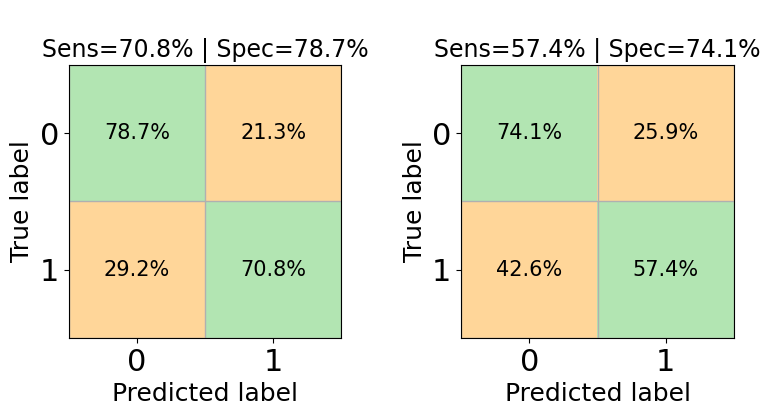

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

import numpy as np
import matplotlib.pyplot as plt

# def plot_cm_pct_colored(ax, cm, title, fs=14):
#     cm = np.asarray(cm, float)
#     pct = 100 * cm / cm.sum()

#     # cell colors: [[TN, FP],[FN, TP]]
#     green  = np.array([0.70, 0.90, 0.70, 1.0])  # light green RGBA
#     orange = np.array([1.00, 0.84, 0.60, 1.0])  # light orange RGBA
#     colors = np.array([[green,  orange],
#                        [orange, green ]])

#     ax.imshow(colors, interpolation="nearest")
#     ax.set_title(title, fontsize=fs+2)
#     ax.set_xticks([0,1]); ax.set_yticks([0,1])
#     ax.set_xticklabels([0,1], fontsize=fs)
#     ax.set_yticklabels([0,1], fontsize=fs)
#     ax.set_xlabel("Predicted label", fontsize=fs)
#     ax.set_ylabel("True label", fontsize=fs)

#     # percent text only
#     for (i, j), _ in np.ndenumerate(cm):
#         ax.text(j, i, f"{pct[i,j]:.1f}%", ha="center", va="center", fontsize=fs)
#         #ax.text(j, i, f"{int(cm[i,j])}\n({pct[i,j]:.1f}%)",ha="center", va="center", fontsize=fs)

#     # optional: thin grid lines between cells
#     ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
#     ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
#     ax.grid(which="minor", linestyle="-", linewidth=1)
#     ax.tick_params(which="minor", bottom=False, left=False)

def plot_cm_pct_colored(ax, cm, title, fs=14):
    cm = np.asarray(cm, float)
    pct = 100 * cm / cm.sum(axis=1, keepdims=True)  # row-wise is usually better

    tn, fp, fn, tp = cm.ravel()
    sens = 100 * tp / (tp + fn)
    spec = 100 * tn / (tn + fp)

    green  = np.array([0.70, 0.90, 0.70, 1.0])
    orange = np.array([1.00, 0.84, 0.60, 1.0])
    colors = np.array([[green,  orange],
                       [orange, green ]])

    ax.imshow(colors, interpolation="nearest")
    ax.set_title(f"{title}\nSens={sens:.1f}% | Spec={spec:.1f}%", fontsize=fs+2)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels([0,1], fontsize=22)
    ax.set_yticklabels([0,1], fontsize=22)
    ax.set_xlabel("Predicted label", fontsize=18)
    ax.set_ylabel("True label", fontsize=18)

    for (i, j), _ in np.ndenumerate(cm):
        ax.text(j, i, f"{pct[i,j]:.1f}%", ha="center", va="center", fontsize=fs)
        # ax.text(j, i, f"{int(cm[i,j])}\n({pct[i,j]:.1f}%)",
        #         ha="center", va="center", fontsize=fs)

    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
plot_cm_pct_colored(ax[0], cm_tr_sum, "", fs=15)
plot_cm_pct_colored(ax[1], cm_te_sum, "",  fs=15)
#plot_cm_pct_colored(ax[2], oof_cm,     "OOF TEST CM (%)",        fs=12)
plt.tight_layout(); plt.show()

In [5]:
(521+115+96+552)/107/3, (109+50+44+118)/107/3

(4.0, 1.0)

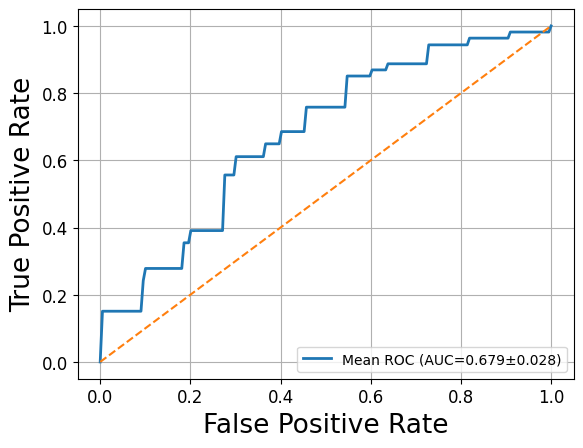

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import roc_curve, roc_auc_score

# Use the tuned best hyperparams, but refit per fold
best_params = rs.best_params_

plt.figure()

aucs = []
mean_fpr = np.linspace(0, 1, 200)
tprs = []

for fold_i, (tr, te) in enumerate(cv.split(X, y, groups=groups), 1):
    m = clone(rs.best_estimator_)
    m.set_params(**best_params)
    m.fit(X[tr], y[tr])

    proba = m.predict_proba(X[te])[:, 1]
    fpr, tpr, _ = roc_curve(y[te], proba)
    auc = roc_auc_score(y[te], proba)

    aucs.append(auc)
    #plt.plot(fpr, tpr, label=f"Fold {fold_i} (AUC={auc:.3f})")

    # for mean ROC
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0

# Mean ROC
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

plt.plot(mean_fpr, mean_tpr, linewidth=2, label=f"Mean ROC (AUC={mean_auc:.3f}±{std_auc:.3f})")

# Diagonal
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.title("ROC Curves (5-fold patient-wise CV)")
plt.xlabel("False Positive Rate", fontsize=19)
plt.ylabel("True Positive Rate", fontsize=19)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# print("Fold AUCs:", [round(a, 3) for a in aucs])
# print(f"Mean±std AUC: {mean_auc:.3f}±{std_auc:.3f}")


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.09301280975341797s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  22 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  38 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  60 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done  91 out of 107 | elapsed:    0.7s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 102 out of 107 | elapsed:    0.8s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 107 out of 107 | elapsed:    0.8s finished


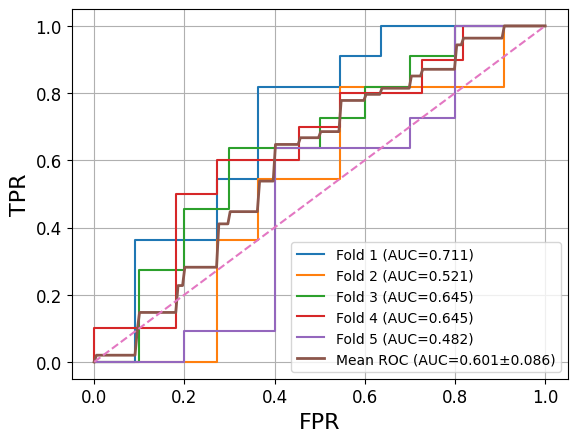

In [7]:
from sklearn.base import clone
from sklearn.metrics import roc_curve, roc_auc_score
def build_samples_one_per_patient(output_dir: str):
    files = sorted(glob.glob(os.path.join(output_dir, "CIPN3*.xlsx")))
    rows = []
    seen = set()
    for f in files:
        pid = parse_patient_id_from_filename(f)
        if pid is None:
            continue
        if pid in seen:
            continue
        seen.add(pid)
        rows.append((pid, f))
    return rows
    
def make_Xy_groups_from_dir(output_dir: str, one_per_patient=False):
    rows = build_samples_one_per_patient(output_dir) if one_per_patient else build_samples(output_dir)
    rows = [(pid, f) for (pid, f) in rows if pid in diff.index]
    if len(rows) == 0:
        raise RuntimeError(f"No samples found in {output_dir} after filtering for labeled patients.")
    kept_files = [f for _, f in rows]
    y = np.asarray([int(pid_to_y[pid]) for pid, _ in rows], dtype=int)
    groups = np.asarray([pid for pid, _ in rows], dtype=int)
    X_list = Parallel(n_jobs=-1, prefer="processes", verbose=10)(
        delayed(load_one_file_all_features)(f, SHEET_BANDS) for f in kept_files)
    X = np.vstack(X_list).astype(float)
    return X, y, groups, kept_files
    
clean_dir = "processeddata/"   # non-aug
X_clean, y_clean, groups_clean, files_clean = make_Xy_groups_from_dir(clean_dir, one_per_patient=True)


cv_clean = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
best_params = rs.best_params_

plt.figure()
aucs, tprs = [], []
mean_fpr = np.linspace(0, 1, 200)

for i, (tr, te) in enumerate(cv_clean.split(X_clean, y_clean, groups=groups_clean), 1):
    m = clone(rs.best_estimator_)
    m.set_params(**best_params)
    m.fit(X_clean[tr], y_clean[tr])

    p = m.predict_proba(X_clean[te])[:, 1]
    fpr, tpr, _ = roc_curve(y_clean[te], p)
    auc = roc_auc_score(y_clean[te], p)

    plt.plot(fpr, tpr, label=f"Fold {i} (AUC={auc:.3f})")
    aucs.append(auc)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0

mean_tpr = np.mean(tprs, axis=0); mean_tpr[-1] = 1.0
plt.plot(mean_fpr, mean_tpr, linewidth=2, label=f"Mean ROC (AUC={np.mean(aucs):.3f}±{np.std(aucs):.3f})")
plt.plot([0,1],[0,1],"--")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.title("ROC on CLEAN (patient-wise 5-fold CV, fixed hyperparams)")
plt.xlabel("FPR", fontsize=16); plt.ylabel("TPR", fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


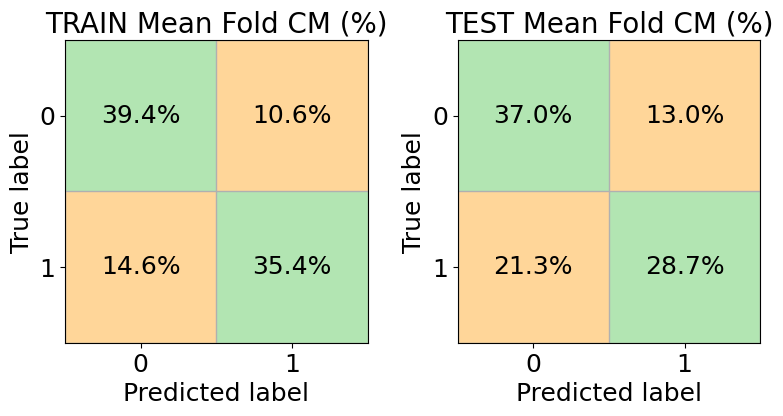

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score

def cv_train_test_confusion_matrices(
    X, y, groups, cv, estimator_template, best_params, thr=0.5
):
    cms_tr, cms_te = [], []
    bas_tr, bas_te = [], []
    oof_proba = np.full(len(y), np.nan, dtype=float)

    for fold_i, (tr, te) in enumerate(cv.split(X, y, groups=groups), 1):
        m = clone(estimator_template)
        m.set_params(**best_params)
        m.fit(X[tr], y[tr])

        # ---- TRAIN metrics (on tr)
        proba_tr = m.predict_proba(X[tr])[:, 1]
        pred_tr = (proba_tr >= thr).astype(int)
        cm_tr = confusion_matrix(y[tr], pred_tr, labels=[0, 1])
        ba_tr = balanced_accuracy_score(y[tr], pred_tr)
        cms_tr.append(cm_tr); bas_tr.append(ba_tr)

        # ---- TEST metrics (on te)
        proba_te = m.predict_proba(X[te])[:, 1]
        oof_proba[te] = proba_te
        pred_te = (proba_te >= thr).astype(int)
        cm_te = confusion_matrix(y[te], pred_te, labels=[0, 1])
        ba_te = balanced_accuracy_score(y[te], pred_te)
        cms_te.append(cm_te); bas_te.append(ba_te)

    # Mean/std CMs (equal weight per fold)
    mean_cm_tr = np.mean(np.stack(cms_tr, axis=0), axis=0)
    std_cm_tr  = np.std(np.stack(cms_tr, axis=0), axis=0)

    mean_cm_te = np.mean(np.stack(cms_te, axis=0), axis=0)
    std_cm_te  = np.std(np.stack(cms_te, axis=0), axis=0)

    # OOF CM (micro-averaged TEST across all samples)
    assert np.all(np.isfinite(oof_proba))
    oof_pred = (oof_proba >= thr).astype(int)
    oof_cm = confusion_matrix(y, oof_pred, labels=[0, 1])

    return (mean_cm_tr, std_cm_tr, np.array(bas_tr),
            mean_cm_te, std_cm_te, np.array(bas_te),
            oof_cm, oof_proba)

best_params = rs.best_params_

(mean_cm_tr, std_cm_tr, fold_ba_tr,
 mean_cm_te, std_cm_te, fold_ba_te,
 oof_cm, oof_proba) = cv_train_test_confusion_matrices(
    X=X, y=y, groups=groups, cv=cv,
    estimator_template=rs.best_estimator_,
    best_params=best_params,
    thr=0.5
)

# print("\nTRAIN fold bal_acc:", np.round(fold_ba_tr, 3))
# print(f"TRAIN Mean±std bal_acc: {fold_ba_tr.mean():.3f}±{fold_ba_tr.std():.3f}")
# print("\nTRAIN Mean CM across folds (thr=0.5):")
# print("[[TN FP], [FN TP]]")
# print(np.round(mean_cm_tr, 2))
# print("\nTRAIN Std CM across folds:")
# print(np.round(std_cm_tr, 2))

# print("\nTEST fold bal_acc:", np.round(fold_ba_te, 3))
# print(f"TEST  Mean±std bal_acc: {fold_ba_te.mean():.3f}±{fold_ba_te.std():.3f}")
# print("\nTEST Mean CM across folds (thr=0.5):")
# print("[[TN FP], [FN TP]]")
# print(np.round(mean_cm_te, 2))
# print("\nTEST Std CM across folds:")
# print(np.round(std_cm_te, 2))

# print("\nOOF TEST CM (all out-of-fold preds, thr=0.5):")
# print("[[TN FP], [FN TP]]")
# print(oof_cm)

# # ---- Plot TRAIN mean CM, TEST mean CM, and OOF CM
# fig, ax = plt.subplots(1, 3, figsize=(14, 4))

# ConfusionMatrixDisplay(confusion_matrix=np.round(mean_cm_tr, 0).astype(int), display_labels=[0, 1]).plot(ax=ax[0], values_format="d")
# ax[0].set_title("TRAIN Mean Fold CM (rounded)")

# ConfusionMatrixDisplay(confusion_matrix=np.round(mean_cm_te, 0).astype(int), display_labels=[0, 1]).plot(ax=ax[1], values_format="d")
# ax[1].set_title("TEST Mean Fold CM (rounded)")

# ConfusionMatrixDisplay(confusion_matrix=oof_cm, display_labels=[0, 1]).plot(ax=ax[2], values_format="d")
# ax[2].set_title("OOF TEST CM")

# plt.tight_layout()
# plt.show()


#####################################

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

import numpy as np
import matplotlib.pyplot as plt

def plot_cm_pct_colored(ax, cm, title, fs=14):
    cm = np.asarray(cm, float)
    pct = 100 * cm / cm.sum()

    # cell colors: [[TN, FP],[FN, TP]]
    green  = np.array([0.70, 0.90, 0.70, 1.0])  # light green RGBA
    orange = np.array([1.00, 0.84, 0.60, 1.0])  # light orange RGBA
    colors = np.array([[green,  orange],
                       [orange, green ]])

    ax.imshow(colors, interpolation="nearest")
    ax.set_title(title, fontsize=fs+2)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels([0,1], fontsize=fs)
    ax.set_yticklabels([0,1], fontsize=fs)
    ax.set_xlabel("Predicted label", fontsize=fs)
    ax.set_ylabel("True label", fontsize=fs)

    # percent text only
    for (i, j), _ in np.ndenumerate(cm):
        ax.text(j, i, f"{pct[i,j]:.1f}%", ha="center", va="center", fontsize=fs)

    # optional: thin grid lines between cells
    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
plot_cm_pct_colored(ax[0], mean_cm_tr, "TRAIN Mean Fold CM (%)", fs=18)
plot_cm_pct_colored(ax[1], mean_cm_te, "TEST Mean Fold CM (%)",  fs=18)
#plot_cm_pct_colored(ax[2], oof_cm,     "OOF TEST CM (%)",        fs=12)
plt.tight_layout(); plt.show()


In [11]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.8/562.8 kB 12.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]


100%|██████████| 108/108 [00:01<00:00, 69.94it/s]


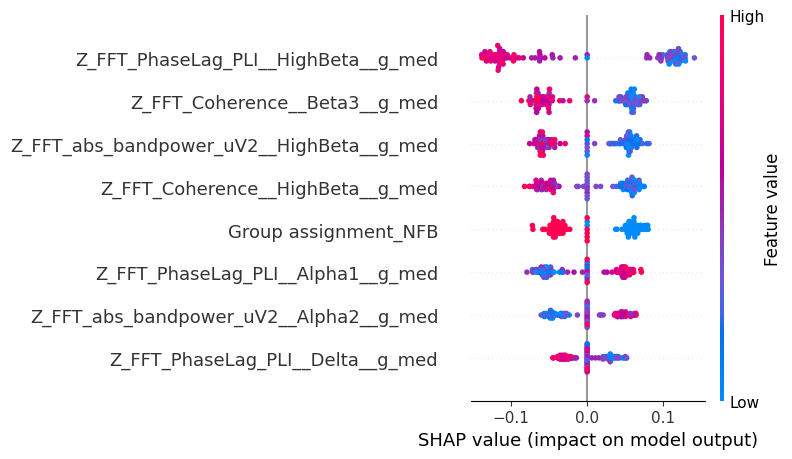

In [12]:
import os, numpy as np, pandas as pd, shap, matplotlib.pyplot as plt

# ----------------------------
# 0) settings
# ----------------------------
TOP_N = 8
N_BG = 80
N_EVAL = 250
NSAMPLES = 300
SAVE_DIR = "reports/shap_out"
os.makedirs(SAVE_DIR, exist_ok=True)

# ----------------------------
# 1) build EEG feature names (same order as your load_one_file_all_features)
# ----------------------------
def build_eeg_feature_names(sheet_bands: dict, mode: str):
    if mode == "mean":
        stats = ["g_mean"]
    elif mode == "mean_std":
        stats = ["g_mean", "g_std"]
    elif mode == "mean_median":
        stats = ["g_mean", "g_med"]
    elif mode == "all5":
        stats = ["col_mean", "col_std", "g_mean", "g_std", "g_med"]
    else:
        raise ValueError("Invalid BAND_FEATS_MODE")

    names = []
    for sheet, bands in sheet_bands.items():
        for band in bands:
            for st in stats:
                names.append(f"{sheet}__{band}__{st}")
    return names

eeg_names = build_eeg_feature_names(SHEET_BANDS, BAND_FEATS_MODE)

# cov_feat_cols already exists in your pipeline (from get_dummies)
all_feature_names = eeg_names + list(cov_feat_cols)

# sanity check
if X.shape[1] != len(all_feature_names):
    raise RuntimeError(f"Name mismatch: X has {X.shape[1]} cols but names has {len(all_feature_names)}")

X_df = pd.DataFrame(X, columns=all_feature_names)

# ----------------------------
# 2) SHAP with names (KernelExplainer)
# ----------------------------
best_est = rs.best_estimator_
best_est.fit(X_df.values, y)

rng = np.random.default_rng(42)
bg_idx = rng.choice(len(y), size=min(N_BG, len(y)), replace=False)
ev_idx = rng.choice(len(y), size=min(N_EVAL, len(y)), replace=False)

X_bg = X_df.iloc[bg_idx]
X_ev = X_df.iloc[ev_idx]

def p1(data_2d):
    data_2d = np.asarray(data_2d)
    return best_est.predict_proba(data_2d)[:, 1]

explainer = shap.KernelExplainer(p1, X_bg.values)
shap_values = explainer.shap_values(X_ev.values, nsamples=NSAMPLES)

plt.figure()
shap.summary_plot(shap_values, X_ev, show=False, max_display=TOP_N)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, f"shap_beeswarm_top{TOP_N}.png"), dpi=200)
plt.show()


100%|██████████| 108/108 [00:01<00:00, 78.48it/s]


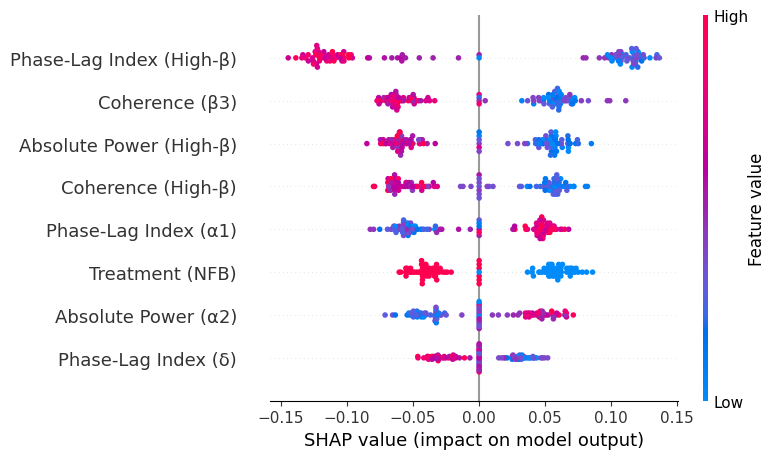

In [13]:
import os, numpy as np, pandas as pd, shap, matplotlib.pyplot as plt

# ----------------------------
# 0) settings
# ----------------------------
TOP_N = 8
N_BG = 80
N_EVAL = 250
NSAMPLES = 300
SAVE_DIR = "reports/shap_out"
os.makedirs(SAVE_DIR, exist_ok=True)

# ----------------------------
# 1) build EEG feature names
# ----------------------------
def build_eeg_feature_names(sheet_bands, mode):
    stats = {
        "mean": ["g_mean"],
        "mean_std": ["g_mean", "g_std"],
        "mean_median": ["g_mean", "g_med"],
        "all5": ["col_mean", "col_std", "g_mean", "g_std", "g_med"],
    }[mode]
    return [
        f"{sheet}__{band}__{st}"
        for sheet, bands in sheet_bands.items()
        for band in bands
        for st in stats
    ]

eeg_names = build_eeg_feature_names(SHEET_BANDS, BAND_FEATS_MODE)
all_feature_names = eeg_names + list(cov_feat_cols)

if X.shape[1] != len(all_feature_names):
    raise RuntimeError(f"Name mismatch: X has {X.shape[1]} cols but names has {len(all_feature_names)}")

X_df = pd.DataFrame(X, columns=all_feature_names)

# ----------------------------
# 2) pretty names for plotting
# ----------------------------
band_map = {
    "Delta": "δ", "Theta": "θ", "Alpha": "α", "Alpha1": "α1", "Alpha2": "α2",
    "Beta": "β", "Beta1": "β1", "Beta2": "β2", "Beta3": "β3", "HighBeta": "High-β", "Gamma": "γ"
}
measure_map = {
    "Z_FFT_Coherence": "Coherence",
    "Z_FFT_PhaseLag_PLI": "Phase-Lag Index",
    "Z_FFT_abs_bandpower_uV2": "Absolute Power",
}
cov_map = {
    "Group assignment_NFB": "Treatment (NFB)",
    "Group assignment_NFB+DL": "Treatment (NFB+DL)",
    "Group assignment_DL": "Treatment (DL)",
    "CancerStage_3_I_II": "Cancer Stage (I/II)",
    "CancerStage_3_III": "Cancer Stage (III)",
    "CancerStage_3_IV": "Cancer Stage (IV)",
    "Sex_Female": "Sex (Female)",
    "Sex_Male": "Sex (Male)",
    "Married": "Married",
}

def pretty_name(name):
    if "__" not in name:
        return cov_map.get(name, name)
    measure, band, _ = name.split("__")
    return f"{measure_map.get(measure, measure)} ({band_map.get(band, band)})"

X_plot = X_df.copy()
X_plot.columns = [pretty_name(c) for c in X_df.columns]

# ----------------------------
# 3) SHAP with names
# ----------------------------
best_est = rs.best_estimator_
best_est.fit(X_df.values, y)

rng = np.random.default_rng(42)
bg_idx = rng.choice(len(y), size=min(N_BG, len(y)), replace=False)
ev_idx = rng.choice(len(y), size=min(N_EVAL, len(y)), replace=False)

X_bg = X_df.iloc[bg_idx]
X_ev = X_df.iloc[ev_idx]
X_ev_plot = X_plot.iloc[ev_idx]

def p1(data_2d):
    return best_est.predict_proba(np.asarray(data_2d, dtype=float))[:, 1]

explainer = shap.KernelExplainer(p1, X_bg.values)
shap_values = explainer.shap_values(X_ev.values, nsamples=NSAMPLES)

if isinstance(shap_values, list):
    shap_values = shap_values[1] if len(shap_values) == 2 else shap_values[0]

# ----------------------------
# 4) save beeswarm
# ----------------------------
plt.figure(figsize=(9, 5.5))
shap.summary_plot(shap_values, X_ev_plot, show=False, max_display=TOP_N)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, f"shap_beeswarm_top{TOP_N}.png"), dpi=200, bbox_inches="tight")
plt.show()


In [ ]:
What “right vs left” means on a SHAP beeswarm
Right (positive SHAP value) → pushes the model output up → higher predicted probability of class 1.
Left (negative SHAP value) → pushes the model output down → higher predicted probability of class 0.

class 1 ⇔ Diff >= median_threshold
class 0 ⇔ Diff < median_threshold (more negative than -3.0)

In [14]:
import os, glob, re
import pandas as pd
from collections import Counter

output_dir = "processeddata/"

def parse_patient_id_from_filename(xlsx_path: str):
    base = os.path.basename(xlsx_path)
    m = re.search(r"CIPN3(\d{3})", base)
    return int(m.group(1)) if m else None

files = sorted(glob.glob(os.path.join(output_dir, "CIPN3*.xlsx")))
rows = []
for f in files:
    pid = parse_patient_id_from_filename(f)
    if pid is not None:
        rows.append((pid, f))

# count files per patient
cnt = Counter(pid for pid, _ in rows)
df_cnt = pd.DataFrame(sorted(cnt.items()), columns=["pid", "n_files"])

print("Total files:", len(rows))
print("Unique pids:", df_cnt.shape[0])
print("\nPatients with != 3 files:")
print(df_cnt[df_cnt["n_files"] != 3].sort_values(["n_files","pid"], ascending=[False, True]))

# show filenames for the offenders (this will reveal the +3)
offenders = df_cnt[df_cnt["n_files"] != 3]["pid"].tolist()
for pid in offenders:
    print("\n" + "="*80)
    print("PID", pid, "n_files =", cnt[pid])
    for _, f in sorted([r for r in rows if r[0] == pid], key=lambda x: os.path.basename(x[1])):
        print("  ", os.path.basename(f))


Total files: 108
Unique pids: 107

Patients with != 3 files:
     pid  n_files
55   124        2
0      1        1
1      2        1
2      5        1
3      6        1
..   ...      ...
102  253        1
103  261        1
104  283        1
105  328        1
106  330        1

[107 rows x 2 columns]

PID 1 n_files = 1
   CIPN3001_NFB.xlsx

PID 2 n_files = 1
   CIPN3002_NFB_DUL.xlsx

PID 5 n_files = 1
   CIPN3005_NFB.xlsx

PID 6 n_files = 1
   CIPN3006_NFB.xlsx

PID 7 n_files = 1
   CIPN3007_NFB.xlsx

PID 8 n_files = 1
   CIPN3008_NFB.xlsx

PID 9 n_files = 1
   CIPN3009_NFB.xlsx

PID 10 n_files = 1
   CIPN3010_NFB.xlsx

PID 11 n_files = 1
   CIPN3011_NFB.xlsx

PID 12 n_files = 1
   CIPN3012_NFB_DUL.xlsx

PID 13 n_files = 1
   CIPN3013_NFB_DUL.xlsx

PID 17 n_files = 1
   CIPN3017_NFB.xlsx

PID 18 n_files = 1
   CIPN3018_DUL.xlsx

PID 20 n_files = 1
   CIPN3020_DUL.xlsx

PID 26 n_files = 1
   CIPN3026_NFB.xlsx

PID 29 n_files = 1
   CIPN3029_DUL.xlsx

PID 31 n_files = 1
   CIPN3031_NFB.xl

In [32]:
108/3, 213/3

(36.0, 71.0)